# Bird CLEF 2026 Japanese Tutorial (日本語チュートリアル)
このノートブックでは、環境音データを調査し、鳥の種類を予測するためのベースラインモデルを実装します。

![Bird CLEF](https://www.kaggle.com/competitions/129329/images/header)

## コンペティション概要
BirdCLEFは、Kaggle上で開催される**生物音響（bioacoustics）×機械学習**の国際コンペであり、<br>
自然環境で録音された音声から鳥類の種を識別するAIモデルを開発することが目的です。<br>
具体的には、**野外に設置された録音機器（Passive Acoustic Monitoring）や長時間の環境音(soundscape)** から鳥の鳴き声を検出し、
どの種の鳥かを分類するモデルを作成します。

この種のタスクは、生態学・環境科学・保全科学において重要な問題です。<br>
機械学習により、研究者が大量の音声データを自動解析できるようになります。<br>

---

### 課題設定・目的

森林の音や昆虫の音、複数の鳥が同時に鳴く音といったノイズの多い環境音データ(soundspase)から各音声区間に対して鳥の種類(species)を予測する。つまり、多ラベル音声分類(multi-label audio classification)です。コンペの目的としては以下の3点が存在します。

1. 「鳥類が環境変化や森林破壊、気候変動の影響を敏感に受ける」と言う性質を利用し、鳥類の分布から生態系の健康状態を評価すること
2. 大量の音声データを精密に処理することができるAIモデルを開発することによって従来の専門家による手動解析や種同定の時間や手間を省くこと
3. 十分に研究されていない種やデータの少ない種の鳥類音声を対象とすることで小データ環境での識別方法を開拓すること

参考: [Improving learning-based birdsong classification by utilizing combined audio augmentation strategies](https://www.sciencedirect.com/science/article/pii/S1574954124002413?utm_source=chatgpt.com)

---

### モチベーション・チャレンジ点
モチベーション
1. 生物多様性モニタリングの自動化
世界各地で設置されている自動録音装置により大量の自然音データが収集されているが、専門家による手作業での分析は非常に時間がかかる。
機械学習によって鳥類の鳴き声を自動識別することで、生態系の監視や保全研究を効率化することが期待される。

2. 環境変化の指標としての鳥類
鳥は気候変動や生息環境の変化に敏感な生物であり、その分布や活動を追跡することは環境状態の重要な指標となる。

3. 音響データ解析技術の発展
大規模な自然音データを扱うこの課題は、音声認識、生物音響学、機械学習の交差領域における技術発展を促す。

チャレンジ点
1. 強い環境ノイズ
    - 録音には風・雨・昆虫・人間活動などの雑音が含まれ、鳥の声が埋もれることが多い。

2. 複数種の同時発声（multi-label問題）
    - 一つの音声区間に複数の鳥が同時に鳴くため、単一分類ではなく多ラベル識別が必要。

3. データ不均衡（long-tail distribution）
    - 一部の鳥は大量のデータがある一方、希少種は極端に少なく、モデルが偏りやすい。

4. 弱教師データ（weak labels）
    - 多くのデータでは「録音内に存在する種」は分かるが、正確な発声タイミングは不明。

5. 環境差によるドメインシフト
    - 訓練データと評価データで録音環境や地域が異なり、未知環境への一般化性能が求められる。
---

## 準備

In [1]:
# ライブラリーインポート
#　基本的ライブラリー
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ディスプレイオプション
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set professional plotting style
plt.style.use('ggplot')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.family'] = 'Arial'
custom_palette = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6"]
sns.set_palette(custom_palette)

In [2]:
# データ読み込み
BASE_DIR = "./data"
# BASE_DIR = "/kaggle/input/Title"
train_df = pl.read_csv(
    BASE_DIR + "/train.csv",
    schema_overrides={"primary_label": pl.String}
)
# 同様に他のファイルも型を明示すると安全です
train_lbl_df = pl.read_csv(BASE_DIR + "/train_soundscapes_labels.csv")
taxonomy_df = pl.read_csv(
    BASE_DIR + "/taxonomy.csv",
    schema_overrides={"primary_label": pl.String}
)

datasets = {
    "train data" : train_df,
    "train label": train_lbl_df,
    "taxonomy data"  :  taxonomy_df,
}

## 簡易的データ観察

### 提供データの構成
- **train.csv** : 学習用データセット 
- **train_soundscapes_labels.csv** : 
- **taxonomy.csv** : 
- **sample_submission.csv** : 提出物のサンプル
---

### train.csvの詳細

In [3]:
display(train_df.head())

primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
str,str,str,f64,f64,str,str,str,i64,str,str,f64,str,str,str
"""1161364""","""[]""","""[]""",-22.7562,-46.8666,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat1216197.ogg""","""iNat"""
"""1161364""","""[]""","""[]""",-22.7558,-46.87,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat1114648.ogg""","""iNat"""
"""1161364""","""[]""","""[]""",-22.7547,-46.8728,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat810195.ogg""","""iNat"""
"""1161364""","""[]""","""[]""",-22.7547,-46.8728,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat818781.ogg""","""iNat"""
"""1161364""","""[]""","""[]""",-22.7426,-46.8985,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat556514.ogg""","""iNat"""


- **primary_label** : 種のコード（鳥類の場合はeBirdコード、鳥類以外の場合はiNaturalistの分類群ID）。すべての種に専用ページがあるわけではありません。リンクが機能しない場合もあります。
- **secondary_labels** : 録音者によって記録にも出現するとマークされた種名のリスト。ほとんどnullです。
- **latitude & longitude** : 録音が行われた場所の座標。鳥の種類によっては、鳴き声に地域的な「方言」がある場合があるため、トレーニングデータに地理的な多様性を持たせることをお勧めします。
- **scientific_name** : 科学的な名前。
- **common_name** : 一般的な名前。
- **class_name** : 生物の分類。
- **author** : 録音を提供したユーザー。
- **license** : 提供データのライセンス。
- **rating** : Xeno-canto のユーザーが提供する 1 ～ 5 の値 (1 - 低品質、5 - 高品質、背景種が存在する場合は評価が 0.5 減少)。0 は評価がないことを意味します。iNaturalist は品質評価を提供していません。
- **url** : 音声データのURL。
- **filename** : 関連付けられた音声ファイルの名前。
- **collection** : Xeno-canto のユーザーが提供する 1 ～ 5 の値 (1 - 低品質、5 - 高品質、背景種が存在する場合は評価が 0.5 減少)。0 は評価がないことを意味します。iNaturalist は品質評価を提供していません。

---

### train_soundscapes_labels.csvの詳細

In [4]:
display(train_lbl_df.head())

filename,start,end,primary_label
str,str,str,str
"""BC2026_Train_0039_S22_20211231…","""00:00:00""","""00:00:05""","""22961;23158;24321;517063;65380"""
"""BC2026_Train_0039_S22_20211231…","""00:00:05""","""00:00:10""","""22961;23158;24321;517063;65380"""
"""BC2026_Train_0039_S22_20211231…","""00:00:10""","""00:00:15""","""22961;23158;24321;517063;65380"""
"""BC2026_Train_0039_S22_20211231…","""00:00:15""","""00:00:20""","""22961;23158;24321;517063;65380"""
"""BC2026_Train_0039_S22_20211231…","""00:00:20""","""00:00:25""","""22961;23158;24321;517063;65380"""


- **filename** : BC2026_Test_ <ファイルID> _ <場所>_ <日にち> _<時間(UTC標準時刻)> .ogg
- **start** : 生物音声の開始点。
- **end** : 生物音声の最後点。
- **primary_label** : 音声データに含まれる生物のID。
---

### taxonmy.csvの詳細

In [5]:
display(taxonomy_df.head())

primary_label,inat_taxon_id,scientific_name,common_name,class_name
str,i64,str,str,str
"""1161364""",1161364,"""Guyalna cuta""","""Guyalna cuta""","""Insecta"""
"""116570""",116570,"""Caiman yacare""","""Southern Spectacled Caiman""","""Reptilia"""
"""1176823""",1176823,"""Leptodactylus luctator""","""Wrestler Frog""","""Amphibia"""
"""1491113""",1491113,"""Adenomera guarani""","""Guaraní leaf-litter frog""","""Amphibia"""
"""1595929""",1595929,"""Lysapsus limellum""","""Uruguay Harlequin Frog""","""Amphibia"""


- **primary_label**: 種のコード(train.csvのlabelと共通)。
- **scientific_name**: 科学的な名前。
- **common_name**: 一般的な名前。
- **class_name**: 生物の分類（鳥類、両生類、哺乳動物、昆虫類、爬虫類）を含む、さまざまな種に関するデータ。
--- 

In [6]:
# データの情報
for name, df in datasets.items():
    display(f"<{name}>")
    display(df.shape)

'<train data>'

(35549, 15)

'<train label>'

(1478, 4)

'<taxonomy data>'

(234, 5)

In [7]:
# 統計値の確認
for name, df in datasets.items():
    display(f"<{name}>")
    display(df.describe())

'<train data>'

statistic,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
str,str,str,str,f64,f64,str,str,str,f64,str,str,f64,str,str,str
"""count""","""35549""","""35549""","""35549""",35549.0,35549.0,"""35549""","""35549""","""35549""",35549.0,"""35549""","""35549""",35549.0,"""35549""","""35549""","""35549"""
"""null_count""","""0""","""0""","""0""",0.0,0.0,"""0""","""0""","""0""",0.0,"""0""","""0""",0.0,"""0""","""0""","""0"""
"""mean""",null,null,null,-8.166453,-60.7447,null,null,null,80221.321275,null,null,2.600748,null,null,null
"""std""",null,null,null,20.254421,25.434547,null,null,null,242247.605677,null,null,2.070471,null,null,null
"""min""","""1161364""","""['24279']""","""['', ' canto']""",-54.8574,-159.6556,"""Accipiter striatus""","""Amazonian Motmot""","""Amphibia""",7.0,""" Guillermo Treboux""","""by-nc-sa""",0.0,"""https://static.inaturalist.org…","""1161364/iNat1114648.ogg""","""XC"""
"""25%""",null,null,null,-23.3636,-75.1417,null,null,null,8830.0,null,null,0.0,null,null,null
"""50%""",null,null,null,-14.8825,-58.1302,null,null,null,15957.0,null,null,3.5,null,null,null
"""75%""",null,null,null,4.6429,-48.7335,null,null,null,19627.0,null,null,4.5,null,null,null
"""max""","""yeofly1""","""[]""","""[]""",69.578,175.3239,"""Vanellus chilensis""","""Yungas de la Paz Poison Frog""","""Reptilia""",1.595929e6,"""🪶🐾🍀Nandan Sreejith🦌🍄🌍""","""cc0""",5.0,"""https://xeno-canto.org/999798/…","""yeofly1/iNat999817.ogg""","""iNat"""


'<train label>'

statistic,filename,start,end,primary_label
str,str,str,str,str
"""count""","""1478""","""1478""","""1478""","""1478"""
"""null_count""","""0""","""0""","""0""","""0"""
"""mean""",null,null,null,null
"""std""",null,null,null,null
"""min""","""BC2026_Train_0001_S08_20250606…","""00:00:00""","""00:00:05""","""116570;43435;47158son06;47158s…"
"""25%""",null,null,null,null
"""50%""",null,null,null,null
"""75%""",null,null,null,null
"""max""","""BC2026_Train_0066_S23_20241124…","""00:00:55""","""00:01:00""","""thlwre1"""


'<taxonomy data>'

statistic,primary_label,inat_taxon_id,scientific_name,common_name,class_name
str,str,f64,str,str,str
"""count""","""234""",234.0,"""234""","""234""","""234"""
"""null_count""","""0""",0.0,"""0""","""0""","""0"""
"""mean""",null,128502.901709,null,null,null
"""std""",null,307194.585295,null,null,null
"""min""","""1161364""",7.0,"""Accipiter striatus""","""Amazonian Motmot""","""Amphibia"""
"""25%""",null,10915.0,null,null,null
"""50%""",null,19215.0,null,null,null
"""75%""",null,47158.0,null,null,null
"""max""","""yeofly1""",1.595929e6,"""Vanellus chilensis""","""Yungas de la Paz Poison Frog""","""Reptilia"""


## EDA

### クラス数の調査

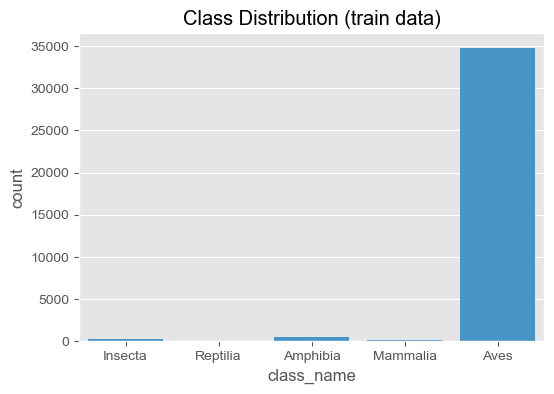

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="class_name", data=train_df)
plt.title("Class Distribution (train data)")
plt.show()

### 考察
5つの生物分類が存在することがわかります。各クラスの名前は日本語だと<br>
**Insecta** : 昆虫類<br>
**Reptilia** : 爬虫類<br>
**Amphibia** : 両生類<br>
**Mammalia** : 哺乳類<br>
**Aves** : 鳥類<br>

当然ではありますが鳥類の数が圧倒的に多いことがわかります。ただし、鳥類の様々な種類が含まれるため学習のために使えるデータが十分であるかは別で確認する必要があります。

In [9]:
# class_name が "Aves" の行を抽出し、primary_label ごとにカウントして降順に並べ替え
aves_summary = (
    train_df
    .filter(pl.col("class_name") == "Aves")         # 鳥類のみをフィルタリング
    .group_by("primary_label")                     # 種ごとにグループ化
    .count()                                       # 各グループのデータ数をカウント
    .sort("count", descending=True)                 # データ数が多い順に並べ替え
)

fig = px.treemap(
    aves_summary, 
    path=['primary_label'], 
    values='count',
    title='Bird Species',
    color='count',
    color_continuous_scale='Viridis'
)
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()
print(f"Total Bird Species: {len(aves_summary)}")

C:\Users\Atsuya_Watanabe\AppData\Local\Temp\ipykernel_51020\3476635515.py:6: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()                                       # 各グループのデータ数をカウント


Total Bird Species: 162


### 考察
今回の学習データの総数はノートブック上部で調査した通り、35549個なので深層学習を使用する場合は最低でも150個のデータは欲しいです。BirdCLEF コンペティションのデータセットは、実は「1種類につき 10件以下」という非常に少ない種のデータが大量に含まれている（ロングテール分布）のが通例です。1回の総数が 35,549 件ある場合、平均すれば 150件前後ある計算になりますが、実際には偏りがあるはずです。データ不足を補う手法として以下が挙げられます：

1. データ拡張 (Data Augmentation):
    - 1つの音声を「少し高くする」「ノイズを混ぜる」「時間をずらす」ことで、擬似的にデータを10倍以上に増やします。これにより、元のデータが10件しかなくても100件相当の学習が可能です。
2. 転移学習 (Transfer Learning):
    - ImageNet（画像）や AudioSet（音声）で学習済みのモデル（EfficientNet や ResNet など）をベースに使うことで、少ないデータでも特徴を捉えやすくします。
3. 外部データの利用:
    - Kaggle のルールで許されている場合、Xeno-canto などの外部サイトからデータを追加で持ってくることがあります。
4. 合成データの作成 (Mixup):
    - 2つの異なる鳥の声を混ぜて新しい学習データを作る手法です。これも BirdCLEF では非常に強力な手法です。

### 収集地点の分布調査

In [10]:
# 密度ベースのマップ
fig = px.density_mapbox(
    train_df.to_pandas(), 
    lat='latitude', 
    lon='longitude', 
    radius=5,
    zoom=1,
    mapbox_style="carto-positron",
    title="録音データの密度マップ (Hotspots)"
)
fig.show()


C:\Users\Atsuya_Watanabe\AppData\Local\Temp\ipykernel_51020\904121971.py:2: DeprecationWarning:

*density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



ロケーションデータ（緯度・経度）は、単に「どこで録音されたか」を知るだけでなく、機械学習モデルの精度を向上させるための非常に強力な武器になります。具体的には、以下のような活用方法があります。: 

1. 生息域による絞り込み<br>
鳥にはそれぞれ固有の「生息域（Species Range）」があります。
    - 活用法: 推論時に、そのロケーションでは絶対に存在しない鳥を候補から外す（または確率を下げる）ことができます。
    - 効果: 「鳴き声が似ている別の地域の鳥」との誤識別を劇的に減らすことができます。
2. 外部データの統合<br>
座標がわかれば、その場所の環境情報を外部から持ってくることができます。
    - 活用法: 座標をもとに、その場所が「森林」「草原」「湿地」のどれに近いか、あるいは気温や降水量などの気候データを結合します。
    - 効果: 特定の環境にしかいない鳥を特定するヒントになります。
3. 補助入力としての利用<br>
    - 活用法: 音声データと一緒に、座標情報をニューラルネットワークに直接入力（Metadata Embedding）させます。
    - 効果: モデル自体が「このあたりならこの鳥がいる可能性が高い」という空間的なパターンの学習を試みるようになります。
4. 「夜明け」や「季節」の推定<br>
座標と日付があれば、その場所の正確な日の出・日の入りの時間や、渡り鳥のシーズンかどうかを計算できます。
    - 活用法: 鳥は早朝に鳴く、あるいは特定の時期にしか鳴かないといった習性があるため、これらは強力な特徴量になります。

### 音声クオリティーの調査

C:\Users\Atsuya_Watanabe\AppData\Local\Temp\ipykernel_51020\180192891.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




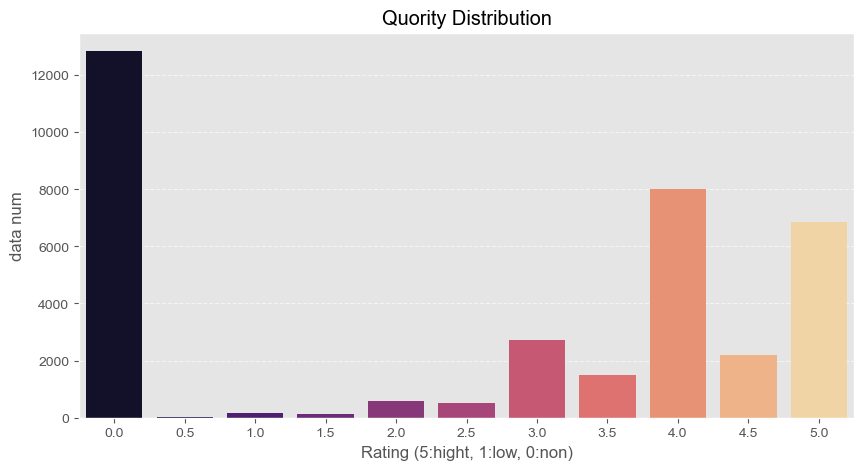

In [11]:
plt.figure(figsize=(10, 5))
# ratingごとのデータ数をカウントして表示
sns.countplot(data=train_df.to_pandas(), x="rating", palette="magma")
plt.title("Quority Distribution")
plt.xlabel("Rating (5:hight, 1:low, 0:non)")
plt.ylabel("data num")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [12]:
print("--- Rating 統計情報 ---")
print(train_df.select("rating").describe())

# 評価が 0 (未評価) のデータの割合
unrated_count = train_df.filter(pl.col("rating") == 0).height
total_count = train_df.height
print(f"\n未評価データ(0): {unrated_count} 件 ({unrated_count/total_count:.1%})")


--- Rating 統計情報 ---
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ rating   │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 35549.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 2.600748 │
│ std        ┆ 2.070471 │
│ min        ┆ 0.0      │
│ 25%        ┆ 0.0      │
│ 50%        ┆ 3.5      │
│ 75%        ┆ 4.5      │
│ max        ┆ 5.0      │
└────────────┴──────────┘

未評価データ(0): 12849 件 (36.1%)


### 考察
データの品質によってデータの重要度をモデルに反映させることができます。具体的には以下のような活用の仕方があります。
- フィルタリング: 学習の初期段階では rating >= 3.0 の高品質なデータのみを使って「きれいな特徴量」をモデルに覚えさせ、後半で低品質なデータを入れて堅牢性を高める、といった戦略が取れます。
- ウェイト付け: 損失関数（Loss Function）を計算する際に、rating が高いデータの重みを大きくすることで、正確なラベルから重点的に学習させることができます。

## データ考察と戦略立案

これまでの分析（クラス不均衡、ロケーション、クオリティ）を踏まえ、BirdCLEFコンペティションで即戦力となる「手軽なテクニック」と、推奨される「モデル戦略」をまとめました。

**手軽に導入できる3つのテクニック**
これまでの考察を具体的な実装アイデアに落とし込むと、以下の3つが「低コスト・高リターン」でおすすめです。

1. クラスウェイトまたはダウンサンプリング（不均衡対策）
    - 内容: 種ごとのデータ数の差を埋めます。
    - やり方: データ数が多い種の学習頻度を下げ、逆に少ない種（ヒストグラムの左側にあった種）を繰り返し学習させるか、Loss関数で高い重みを設定します。
    - 効果: 希少種を無視して「とりあえず多い種のラベルを出しておけば当たる」というモデルの怠慢を防ぎます。
2. ロケーション・フィルタリング（後処理）
    - 内容: 地図の分析で判明した「この地域にはこの鳥はいない」という知識を、予測結果に掛け合わせます。
    - やり方: 各地点ごとの「出現可能性リスト（Species Range）」を作成し、リストにない鳥の予測確率を 0 にする、あるいは大幅に下げます。
    - 効果: 似た鳴き声を持つ「別の場所の鳥」への誤検知を劇的に減らせます。
3. クオリティ・フィルタリング（学習時の選別）
    - 内容: rating の値を信頼度として使います。
    - やり方: 学習の最初の数エポックは rating >= 3.0 のデータのみを使用し、モデルが鳥の「きれいな声」を覚えてから、徐々に低クオリティなデータを混ぜていきます（カリキュラム学習の簡易版）。
    - 効果: 背景ノイズによる学習の混乱を防ぎ、収束が早まります。


### 戦略の実行

In [13]:
# 1. クオリティ・フィルタリング
# 高品質なデータ (Rating 3.0以上) のみを抽出
high_quality_train = train_df.filter(pl.col("rating") >= 3.0)

print(f"元のデータ数: {len(train_df)}")
print(f"高品質なデータ数: {len(high_quality_train)}")


元のデータ数: 35549
高品質なデータ数: 21295


In [14]:
# 2. クラス不均衡対策（重みの計算）
# 各種ごとのデータ数をカウント
species_counts = train_df.group_by("primary_label").count()

# 重みの計算: 1 / (その鳥の総数)
# これにより、データの少ない鳥ほど1行あたりの重みが大きくなります
species_weights = species_counts.with_columns(
    weight = 1.0 / pl.col("count")
)

# 元のデータフレームに重み情報を結合
train_weighted = train_df.join(species_weights.select(["primary_label", "weight"]), on="primary_label")

display(train_weighted.head())


C:\Users\Atsuya_Watanabe\AppData\Local\Temp\ipykernel_51020\668330586.py:3: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection,weight
str,str,str,f64,f64,str,str,str,i64,str,str,f64,str,str,str,f64
"""1161364""","""[]""","""[]""",-22.7562,-46.8666,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat1216197.ogg""","""iNat""",0.090909
"""1161364""","""[]""","""[]""",-22.7558,-46.87,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat1114648.ogg""","""iNat""",0.090909
"""1161364""","""[]""","""[]""",-22.7547,-46.8728,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat810195.ogg""","""iNat""",0.090909
"""1161364""","""[]""","""[]""",-22.7547,-46.8728,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat818781.ogg""","""iNat""",0.090909
"""1161364""","""[]""","""[]""",-22.7426,-46.8985,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat556514.ogg""","""iNat""",0.090909


In [15]:
# 3. ロケーション・マッピング
# 緯度・経度を少し丸めて「エリア（Grid）」を作成
grid_size = 5.0  
location_map = (
    train_df
    .with_columns([
        (pl.col("latitude") / grid_size).round(0) * grid_size,
        (pl.col("longitude") / grid_size).round(0) * grid_size
    ])
    .group_by(["latitude", "longitude"])
    .agg(
        # そのエリアで観測された鳥のユニークなリストを作成
        possible_species = pl.col("primary_label").unique()
    )
)

display(location_map.head())


latitude,longitude,possible_species
f64,f64,list[str]
50.0,30.0,"[""47144"", ""houspa""]"
20.0,100.0,"[""redjun""]"
40.0,-10.0,"[""bucpar"", ""osprey"", ""houspa""]"
45.0,-85.0,"[""osprey"", ""greyel"", ""shshaw""]"
50.0,-10.0,"[""houspa""]"


## モデル構築と予測

今回はEfficientNetを使用して実験を行っていきます。EfficientNetはBird CLEFでは「王道」です。軽量ながら非常に精度が高く、Kaggleでの入賞実績が最も多いモデルの一つです。EfficientNetは主に画像分類で使用される機械学習モデルですが、音声分類タスクでは、「音声をスペクトログラム画像に変換し、それを画像分類モデルに入力する」というアプローチがデファクトスタンダードです。

他の方のノートブックを調査しているとPerch2.0というモデルが広く使用されているという印象を受けました。Perch 2.0 は、Google DeepMindとGoogle Researchが共同開発したオープンソースの生態音響（Bioacoustics）用基盤モデルで、数百万時間の音声データから動物の鳴き声を識別するために設計されているそうです。モデル構造としてはEfficientNet-B3をベースとしているようです。

In [17]:
import torch
import torch.nn as nn
import timm

class BirdModel(nn.Module):
    """
    EfficientNetを使用した音声分類モデル（メルスペクトログラム入力）
    """
    def __init__(self, model_name="efficientnet_b3", num_classes=236, pretrained=True):
        super(BirdModel, self).__init__()
        
        # 1. timmライブラリを使用して学習済みEfficientNetをロード
        # in_chans=3 は通常の色画像入力（スペクトログラムを3chで使用）
        self.model = timm.create_model(model_name, pretrained=pretrained, in_chans=3)
        
        # 2. EfficientNetの最終出力層（Classifier）の入力次元を取得
        # B0の場合は通常1280
        in_features = self.model.classifier.in_features
        
        # 3. 出力層を今回の鳥の種数（num_classes）に合わせて書き換える
        self.model.classifier = nn.Sequential(
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        """
        x: [batch_size, 3, height, width] のテンソル
        スペクトログラムを画像として受け取ります
        """
        logits = self.model(x)
        return logits

# --- モデルのセットアップ ---

# 学習対象となる鳥の総種数を取得
num_bird_species = train_df["primary_label"].n_unique()

# モデルのインスタンス化 (EfficientNet-B0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BirdModel(model_name="efficientnet_b3", num_classes=num_bird_species)
model.to(device)

print(f"Model initialized with {num_bird_species} classes.")
print(f"Device: {device}")

# --- 動作確認（ダミーデータ） ---
dummy_input = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    output = model(dummy_input)
print(f"Output shape: {output.shape}") # [1, 種数] になっていれば成功

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Model initialized with 206 classes.
Device: cuda
Output shape: torch.Size([1, 206])


c:\Users\Atsuya_Watanabe\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning:

`huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Atsuya_Watanabe\.cache\huggingface\hub\models--timm--efficientnet_b3.ra2_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development



In [ ]:
import os
import torch
import torch.nn as nn
import torchaudio
import torchaudio.transforms as T
import timm
from torch.utils.data import Dataset, DataLoader
import polars as pl
from tqdm.notebook import tqdm # ノートブック用のプログレスバー

# 乱数固定（再現性のため）
torch.manual_seed(42)

# --- 設定値 (Hyperparameters) ---
CONFIG = {
    "model_name": "efficientnet_b3",
    "num_epochs": 5,
    "batch_size": 32,
    "learning_rate": 1e-3,
    "sample_rate": 32000,       # BirdCLEF標準のサンプリングレート
    "duration": 5,              # 1サンプルの長さ (5秒)
    "n_mels": 128,              # メル周波数ビンの数
    "image_size": 256,          # EfficientNet-B3 は 300 がデフォですが扱いやすい 256
    "base_dir": BASE_DIR + "/train_audio" # Oggファイルが格納されているフォルダへのパス
}

# デバイス設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [19]:
class BirdDataset(Dataset):
    def __init__(self, df, base_dir, config, is_train=True):
        self.df = df
        self.base_dir = base_dir
        self.config = config
        self.is_train = is_train
        
        # クラス名とIDのマッピング (文字列を0~235の数値ラベルに変換)
        self.labels = df["primary_label"].unique().to_list()
        self.label_to_idx = {label: i for i, label in enumerate(self.labels)}
        self.num_classes = len(self.labels)

        # 音声からメルスペクトログラムへの変換定義
        self.mel_transform = T.MelSpectrogram(
            sample_rate=config["sample_rate"],
            n_mels=config["n_mels"],
            n_fft=1024,
            hop_length=512
        )
        self.amplitude_to_db = T.AmplitudeToDB()
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # データの取得
        row = self.df.row(idx, named=True)
        filename = row["filename"]  # 例: "1161364/iNat1216197.ogg"
        filepath = os.path.join(self.base_dir, filename)
        label_str = row["primary_label"]
        
        # --- 音声の読み込みと長さを5秒に揃える処理 ---
        target_frames = self.config["sample_rate"] * self.config["duration"]
        try:
            # 常に先頭から読むことで処理を軽くする(本番ではランダムクロップを推奨)
            waveform, sr = torchaudio.load(filepath, num_frames=target_frames)
            
            # ステレオの場合はモノラル化 (平均を取る)
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)
                
            # 長さが5秒に満たない場合は、右側をゼロパディング (無音で埋める)
            if waveform.shape[1] < target_frames:
                pad_size = target_frames - waveform.shape[1]
                waveform = torch.nn.functional.pad(waveform, (0, pad_size))
                
        except Exception as e:
            # 万が一ファイルが破損している場合のダミーデータ（オールゼロ）
            waveform = torch.zeros(1, target_frames)

        # --- 画像(スペクトログラム)化 ---
        mel_spec = self.mel_transform(waveform)
        mel_db = self.amplitude_to_db(mel_spec)
        
        # Min-Max スケーリングで 0.0 ~ 1.0 に正規化
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
        
        # EfficientNetの入力[3, H, W]に合わせるため、1chの画像を3つのチャンネルに拡張する
        image = mel_db.expand(3, -1, -1) 
        
        # リサイズ処理
        image = torch.nn.functional.interpolate(
            image.unsqueeze(0), 
            size=(self.config["image_size"], self.config["image_size"]), 
            mode="bilinear"
        ).squeeze(0)
        
        # --- ラベルを One-Hot ベクトル化 (マルチラベル向け) ---
        target = torch.zeros(self.num_classes)
        target[self.label_to_idx[label_str]] = 1.0
        
        # (余裕があれば、secondary_labelsの鳥も 1.0 または 0.5 で設定すると精度が上がります)
        
        return image, target


In [20]:
class BirdCLEFModel(nn.Module):
    def __init__(self, model_name, num_classes, pretrained=True):
        super().__init__()
        # EfficientNet-B3 を作成。in_chans=3 は通常のRGB入力の形式です。
        self.model = timm.create_model(model_name, pretrained=pretrained, in_chans=3)
        
        # 出力層（classifier）を、今回の236鳥種に合わせて付け替える
        in_features = self.model.classifier.in_features
        self.model.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)


In [23]:
def train_model():
    """学習の実行関数"""
    
    # 準備：先ほどフィルタリングしたような綺麗なデータ(high_quality_train)を使用すると良いです。
    # ここでは例として train_df の先頭 1000件 を使ってループが回るかテストします
    # train_sample_df = train_df.head(1000) 
    
    # データローダーの作成
    train_dataset = BirdDataset(train_df, CONFIG["base_dir"], CONFIG)
    train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0)
    
    num_classes = train_dataset.num_classes
    
    # モデル、損失関数、最適化手法の定義
    model = BirdCLEFModel(CONFIG["model_name"], num_classes).to(device)
    
    # BirdCLEFは複数ラベルになり得るため、CrossEntropyではなくBCE(Binary Cross Entropy)を使います
    criterion = nn.BCEWithLogitsLoss() 
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
    
    print(f"Training started on {device}...")
    
    for epoch in range(CONFIG["num_epochs"]):
        model.train()
        running_loss = 0.0
        
        # プログレスバーの表示
        bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['num_epochs']}")
        
        for images, targets in bar:
            images = images.to(device)
            targets = targets.to(device)
            
            # フォワードパス
            outputs = model(images)
            loss = criterion(outputs, targets)
            
            # バックプロパゲーションとパラメータ更新
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            bar.set_postfix({'Loss': f"{loss.item():.4f}"})
            
        epoch_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1} Completed | Average Loss: {epoch_loss:.4f}")

    # 学習済みモデルの保存
    torch.save(model.state_dict(), "efficientnet_b3_birdclef.pth")
    print("Model saved to efficientnet_b3_birdclef.pth")

# 実行（まずはエラーなく動くか少ないデータで試します）
train_model()


Training started on cuda...


Epoch 1/5:   0%|          | 0/1111 [00:00<?, ?it/s]

Epoch 1 Completed | Average Loss: 0.0310


Epoch 2/5:   0%|          | 0/1111 [00:00<?, ?it/s]

Epoch 2 Completed | Average Loss: 0.0291


...

Epoch 3 Completed | Average Loss: 0.0291


Epoch 4/5:   0%|          | 0/1111 [00:00<?, ?it/s]

Epoch 4 Completed | Average Loss: 0.0290


Epoch 5/5:   0%|          | 0/1111 [00:00<?, ?it/s]

Epoch 5 Completed | Average Loss: 0.0290
Model saved to efficientnet_b3_birdclef.pth


In [25]:
import glob
import math

def inference():
    """テストデータ (soundscapes) に対する推論を行う"""
    # 1. 保存したモデルのロード
    model = BirdCLEFModel(CONFIG["model_name"], num_classes=len(train_df["primary_label"].unique()))
    
    # "efficientnet_b3_birdclef.pth" は学習時に保存したファイル名に合わせてください
    # まだ実学習を回していない場合は、ロード部分をコメントアウトすれば未学習モデルで形だけテストできます。
    try:
        model.load_state_dict(torch.load("efficientnet_b3_birdclef.pth", map_location=device))
        print("Trained model weights loaded.")
    except Exception as e:
        print(f"Warning: Could not load weights. Using untrained model for layout testing. ({e})")
        
    model.to(device)
    model.eval() # 推論モードに切り替え
    
    # 2. テスト音声の準備
    # コンペ本番では通常 "test_soundscapes" ディレクトリを使います
    test_audio_dir = BASE_DIR + "/test_soundscapes"
    test_files = glob.glob(f"{test_audio_dir}/*.ogg")
    print(f"Found {len(test_files)} test files.")
    
    # 変換器 (Datasetと同じ設定)
    mel_transform = T.MelSpectrogram(sample_rate=CONFIG["sample_rate"], n_mels=CONFIG["n_mels"], n_fft=1024, hop_length=512).to(device)
    amplitude_to_db = T.AmplitudeToDB().to(device)
    target_frames = CONFIG["sample_rate"] * CONFIG["duration"] # 5秒 = 160000 フレーム

    submission_dict = {
        "row_id": []
    }
    # 各鳥の列を事前に作成して初期化
    labels = train_df["primary_label"].unique().to_list()
    for label in labels:
        submission_dict[label] = []

    # 3. 推論ループ
    with torch.no_grad(): # 推論時は勾配計算をオフにして高速化＆メモリ節約
        for filepath in tqdm(test_files, desc="Predicting Test Files"):
            # ファイル名から filename_id を取得 (例: "soundscape_123.ogg" -> "soundscape_123")
            filename_id = os.path.basename(filepath).split('.')[0]
            
            # 長い音声を一括ロード
            try:
                waveform, sr = torchaudio.load(filepath)
                if waveform.shape[0] > 1:
                    waveform = torch.mean(waveform, dim=0, keepdim=True)
            except Exception as e:
                print(f"Failed to load {filepath}: {e}")
                continue
            
            # 音声の総フレーム数から、5秒のチャンクがいくつ作れるか計算
            num_chunks = math.ceil(waveform.shape[1] / target_frames)
            
            # 5秒ごとにスライスして推論
            for i in range(num_chunks):
                # 切り出す範囲の計算: start_frame ～ end_frame
                start_frame = i * target_frames
                end_frame = min((i + 1) * target_frames, waveform.shape[1])
                chunk = waveform[:, start_frame:end_frame].to(device)
                
                # 最後のチャンクが5秒に満たない場合はゼロ埋め
                if chunk.shape[1] < target_frames:
                    pad_size = target_frames - chunk.shape[1]
                    chunk = torch.nn.functional.pad(chunk, (0, pad_size))
                
                # --- スペクトログラム変換と正則化 (GPU上で高速処理) ---
                mel_spec = mel_transform(chunk)
                mel_db = amplitude_to_db(mel_spec)
                mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
                
                # [1ch, H, W] -> [1, 3ch, H, W] (バッチサイズ1 + 3色対応)
                image = mel_db.expand(3, -1, -1).unsqueeze(0)
                image = torch.nn.functional.interpolate(image, size=(CONFIG["image_size"], CONFIG["image_size"]), mode="bilinear")
                
                # --- 推論 ---
                logits = model(image)
                # モデル出力(Logits)を 0.0 ~ 1.0 の確率(Sigmoid)に変換
                probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
                
                # --- 結果の記録 ---
                # "soundscape_453028782_5" のように、ファイル名_秒数 を row_id にする
                end_seconds = (i + 1) * 5
                row_id = f"{filename_id}_{end_seconds}"
                
                submission_dict["row_id"].append(row_id)
                for j, label in enumerate(labels):
                    submission_dict[label].append(probs[j])

    # 4. DataFrame に変換して保存
    submission_df = pl.DataFrame(submission_dict)
    
    # Pandas形式にして保存 (要件に合わせて)
    submission_df.to_pandas().to_csv("submission.csv", index=False)
    print("Inference completed! Saved to submission.csv")
    return submission_df

# 実行
sub_df = inference()
display(sub_df.head())


Trained model weights loaded.
Found 0 test files.


Predicting Test Files: 0it [00:00, ?it/s]

Inference completed! Saved to submission.csv


row_id,souscr1,wfwduc1,scadov1,209233,yehcar1,litcuc2,barant1,burowl,66971,bucpar,whwpic1,y00678,dwatin1,whbant2,555123,555146,bunibi1,22961,stbwoo2,bucmot4,linwoo1,squcuc1,ragmac1,toctou1,74113,larela1,rufgna3,relser1,23724,1176823,camfli1,64898,bbwduc,grepot1,strowl1,shtnig1,…,sibtan2,orwpar,25214,litnig1,pabspi1,whtdov,23154,compot1,326272,ruftho1,24321,pluibi1,lesgrf1,rebscy1,gycwor1,blheag1,undtin1,greela,plasla1,crbthr1,23158,trokin,65377,116570,varant1,41970,redjun,scther1,22985,astcra1,flawar1,67107,516975,blttit1,whbwar2,244024,osprey
null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


メモ ファイル名から時間の情報を抽出する処理を追加する

### 最後に
ここまで読んでいただきありがとうございました。私はデータ分析の学習のためにkaggleのコンペティションに参加しています。何かアドバイスや疑問点があればお気軽にコメントしてください。日本語でも英語でもどちらでも対応しています。...

参考

BirdCLEF'26 - Acoustic Species Identification | EDA: <br>
[https://www.kaggle.com/code/ibrahimqasimi/birdclef-26-acoustic-species-identification-eda]

Google DeepMind が動物の声を聞き分ける AI モデル 「 Perch 2.0 」をオープンソース化: <br>
[https://aiupdate.blog/google-deepmind-perch-2-open-source-bioacoustics-ai-080825/]

参考文献タイトル: 
[参考文献URL]